# LTI CRN NETWORKS

In [1]:
from lrn_builder.siso_analyzer import SISOAnalyzer
from lrn_builder.make_lti_crn import makeLtiCrn  # type: ignore

import numpy as np
import pandas as pd
import tellurium as te
import matplotlib.pyplot as plt
from scipy import signal

# Making LTI Networks

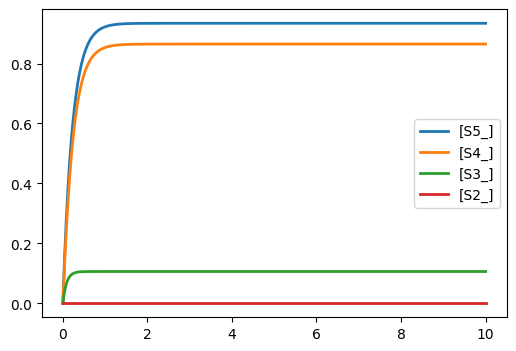

eigenvalues: [-12.3013  -4.3797 -11.3991  -2.5463]
# Random Chemical Reaction Network
# Generated with specified constraints

model random_crn()

  -> $S1_; k1
  S5_ -> 2 S4_ + 3 S4_ + S4_ + 2 S4_ + 3 S4_; k2 * S5_
  S1_ -> 3 S4_ + 2 S5_ + 3 S5_ + S3_ + S3_; k3 * S1_
  S2_ -> 3 S4_ + S3_ + 2 S3_ + S4_ + 3 S5_; k4 * S2_
  S1_ -> S5_; k5 * S1_
  S2_ -> 3 S3_ + 2 S3_ + 2 S3_ + S5_ + S5_; k6 * S2_
  S1_ -> S4_ + 2 S5_ + 2 S4_ + S3_ + S5_; k7 * S1_
  S2_ -> S4_ + 2 S5_ + S3_ + 3 S3_; k8 * S2_
  S2_ -> S4_ + 3 S3_; k9 * S2_
  S1_ -> S5_ + 2 S4_ + S4_; k10 * S1_

  # Rate constants
  k1 = 0.9742
  k2 = 0.7012
  k3 = 0.1698
  k4 = 0.4629
  k5 = 0.5307
  k6 = 0.4652
  k7 = 0.8688
  k8 = 0.8631
  k9 = 0.7551
  k10 = 0.1057

  # Species initialization
  S1_ = 1  # Input boundary species
  S2_ = 0
  S3_ = 0
  S4_ = 0
  S5_ = 0


  # Degradation reactions
  S5_ -> ; kd_0 * S5_
  kd_0 = 3.6785
  S4_ -> ; kd_1 * S4_
  kd_1 = 12.3013
  S3_ -> ; kd_2 * S3_
  kd_2 = 11.3991
end


In [2]:
MODEL = makeLtiCrn(num_species=5,
    num_reaction=10,
    num_products_bounds=[1, 5],
    kinetic_constant_bounds= (0.1, 1),
    stoichiometry_bounds=[1, 3],
    is_input_boundary=True)
rr = te.loada(MODEL)
DATA = rr.simulate(0, 10, 1000)
rr.plot()
mat = rr.getFullJacobian()
print(f"eigenvalues: {np.linalg.eigvals(mat)}")
print(MODEL)

# SISO Analysis

In [3]:
analyzer = SISOAnalyzer(MODEL, output_name="S5_")


In [4]:
tf = analyzer.makeTransferFunction()
print(tf)

ValueError: Expression contains no symbols (it's just a constant)

In [ ]:
times = DATA[:, 0]
_, yv = tf.step(T=times)
plt.plot(times, yv)


In [6]:
tf_smat = analyzer.transfer_function_smat
tf_smat

Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               1.0/(1.0*k10 + 1.0*k3 + 1.0*k5 + 1.0*k7 + 1.0*s), 0, 0, 0, 0],
[                                                                                                                                                                                                                                                                                                                                                                               